# Air Cooler Design & Packed Column Modeling in NeqSim

This notebook demonstrates two new NeqSim process equipment models:

1. **Air-Cooled Heat Exchanger (AirCooler)** — fin-tube thermal design per API 661, including Briggs-Young HTC, Robinson-Briggs pressure drop, fan curves, and ambient temperature correction
2. **Packed Column (PackedColumn)** — absorber/contactor for amine/TEG service with HETP-based staging and packing hydraulics (Eckert flooding, Leva pressure drop, Onda mass transfer)

Both models are fully integrated with NeqSim's `ProcessSystem` for rigorous thermodynamic calculations.

In [1]:
# Setup - Install neqsim if needed and import
import subprocess, sys
try:
    import neqsim
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])

from neqsim import jneqsim
import matplotlib.pyplot as plt
import numpy as np

# Import NeqSim Java classes
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
AirCooler = jneqsim.process.equipment.heatexchanger.AirCooler
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

print("NeqSim loaded successfully")

NeqSim loaded successfully


## Part 1: Air-Cooled Heat Exchanger

### 1.1 Basic Air Cooler Setup

Create a hot natural gas stream and cool it with an air cooler. The AirCooler class provides:
- Humid-air energy balance (psychrometric properties)
- Fin-tube thermal design (Briggs-Young HTC, Schmidt fin efficiency)  
- Bundle sizing (tubes per row, face area, required heat transfer area)
- Fan power estimation (system pressure drop or custom fan curve)
- Ambient temperature correction (ITD-based)

In [2]:
# Create hot natural gas stream
gas = SystemSrkEos(273.15 + 80.0, 30.0)
gas.addComponent("methane", 0.82)
gas.addComponent("ethane", 0.08)
gas.addComponent("propane", 0.05)
gas.addComponent("n-butane", 0.03)
gas.addComponent("CO2", 0.02)
gas.setMixingRule("classic")

hot_gas = Stream("Hot Gas", gas)
hot_gas.setFlowRate(500000.0, "kg/hr")
hot_gas.setTemperature(80.0, "C")
hot_gas.setPressure(30.0, "bara")

# Configure air cooler
ac = AirCooler("AC-101", hot_gas)
ac.setOutletTemperature(40.0, "C")           # Target outlet temperature
ac.setAirInletTemperature(25.0, "C")         # Ambient air at 25°C
ac.setAirOutletTemperature(40.0, "C")        # Air leaves at 40°C
ac.setRelativeHumidity(0.60)                 # 60% RH

# Bundle geometry (API 661 typical)
ac.setTubeOuterDiameter(0.0254)              # 1 inch OD
ac.setFinHeight(0.015875)                    # 5/8 inch fin height
ac.setFinPitch(0.0025)                       # 2.5 mm fin pitch
ac.setFinThickness(0.0004)                   # 0.4 mm aluminium fins
ac.setFinConductivity(200.0)                 # Al conductivity W/m-K
ac.setNumberOfTubeRows(4)
ac.setTubeLength(12.0)                       # 12 m (40 ft) tube length
ac.setBayWidth(3.05)                         # 10 ft bay width
ac.setNumberOfBays(2)
ac.setNumberOfFansPerBay(2)
ac.setFanDiameter(4.27)                      # 14 ft fan diameter

# Run simulation
process = ProcessSystem()
process.add(hot_gas)
process.add(ac)
process.run()

# Display results
print("=" * 60)
print("AIR COOLER AC-101 - Design Results")
print("=" * 60)
print(f"Process: {80.0:.1f}°C → {ac.getOutletStream().getTemperature()-273.15:.1f}°C")
print(f"Duty:              {-ac.getDuty()/1e6:.2f} MW")
print(f"Air mass flow:     {ac.getAirMassFlow():.1f} kg/s")
print(f"Air volume flow:   {ac.getAirVolumeFlow():.1f} m³/s")
print(f"LMTD:              {ac.getLMTD():.1f} K")
print(f"Overall U:         {ac.getOverallU():.1f} W/m²-K")
print(f"Required area:     {ac.getRequiredArea():.1f} m²")
print(f"Air-side HTC:      {ac.getAirSideHTC():.1f} W/m²-K")
print(f"Fin efficiency:    {ac.getFinEfficiency():.3f}")
print(f"Face velocity:     {ac.getFaceVelocity():.2f} m/s")
print(f"Air-side ΔP:       {ac.getAirSidePressureDrop():.1f} Pa")
print(f"Fan power:         {ac.getFanPower('kW'):.1f} kW")
print(f"ITD:               {ac.getITD():.1f} K")
print(f"Total tubes:       {ac.getTotalTubes()}")
print(f"Face area:         {ac.getFaceArea():.1f} m²")

AIR COOLER AC-101 - Design Results
Process: 80.0°C → 40.0°C
Duty:              12.78 MW
Air mass flow:     828.5 kg/s
Air volume flow:   713.1 m³/s
LMTD:              22.9 K
Overall U:         106.3 W/m²-K
Required area:     5237.5 m²
Air-side HTC:      1118.7 W/m²-K
Fin efficiency:    0.828
Face velocity:     9.74 m/s
Air-side ΔP:       298.5 Pa
Fan power:         387.0 kW
ITD:               55.0 K
Total tubes:       408
Face area:         73.2 m²


In [ ]:
### Ambient Temperature Sensitivity Study

Air coolers are strongly affected by ambient temperature. Higher ambient reduces the available temperature driving force (ITD), requiring more air flow or larger bundles. Let's sweep ambient temperature from 10°C to 45°C.

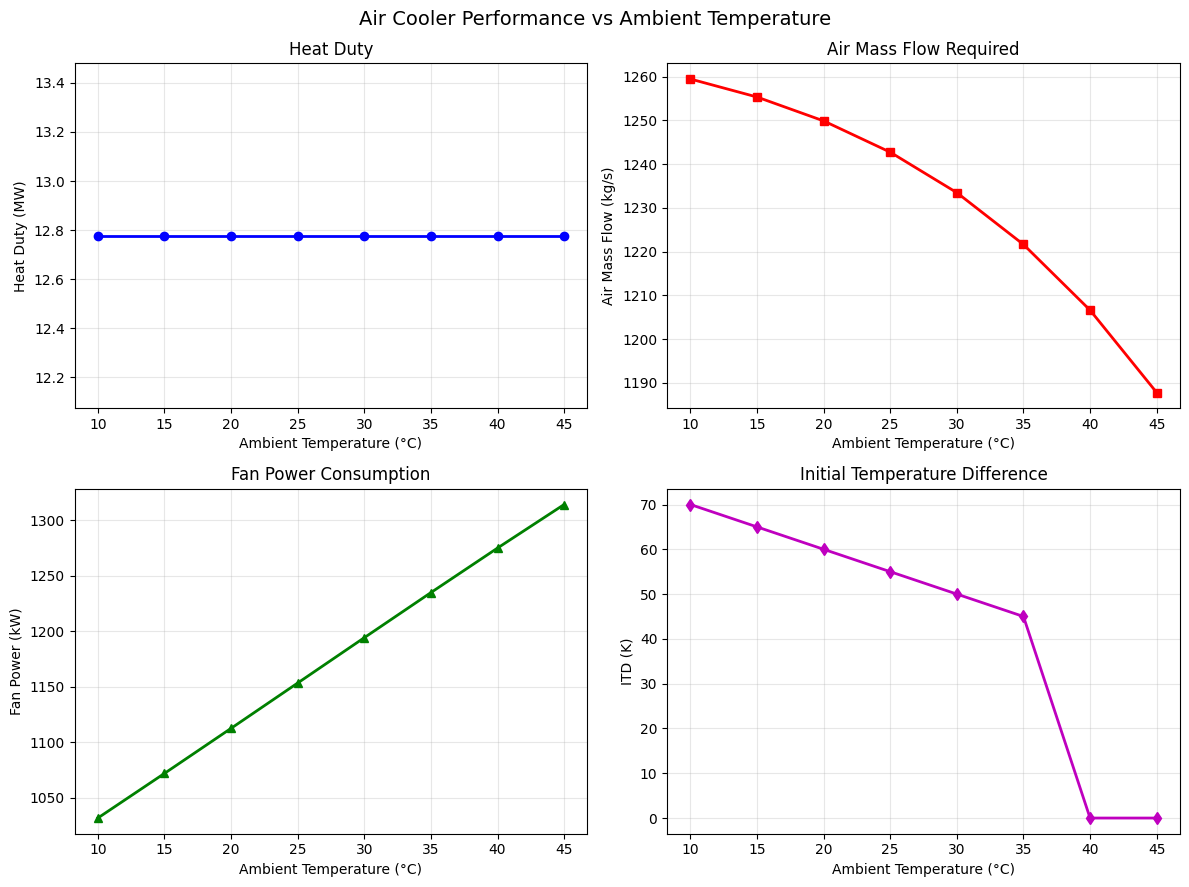

Figure saved: air_cooler_ambient_sensitivity.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

ambient_temps = list(range(10, 46, 5))
duties_mw = []
air_flows = []
fan_powers = []
lmtds = []
itds = []

for t_amb in ambient_temps:
    gas_i = SystemSrkEos(273.15 + 80.0, 30.0)
    gas_i.addComponent("methane", 0.82)
    gas_i.addComponent("ethane", 0.08)
    gas_i.addComponent("propane", 0.05)
    gas_i.addComponent("n-butane", 0.03)
    gas_i.addComponent("CO2", 0.02)
    gas_i.setMixingRule("classic")

    s_i = Stream("feed", gas_i)
    s_i.setFlowRate(500000.0, "kg/hr")
    s_i.setTemperature(80.0, "C")
    s_i.setPressure(30.0, "bara")

    ac_i = AirCooler("AC", s_i)
    ac_i.setOutletTemperature(40.0, "C")
    ac_i.setAirInletTemperature(float(t_amb), "C")
    ac_i.setAirOutletTemperature(float(t_amb + 10), "C")
    ac_i.setRelativeHumidity(0.60)
    ac_i.setNumberOfTubeRows(4)
    ac_i.setTubeLength(12.0)
    ac_i.setBayWidth(3.05)
    ac_i.setNumberOfBays(2)

    ps = ProcessSystem()
    ps.add(s_i)
    ps.add(ac_i)
    ps.run()

    duties_mw.append(-ac_i.getDuty() / 1e6)
    air_flows.append(ac_i.getAirMassFlow())
    fan_powers.append(ac_i.getFanPower("kW"))
    lmtds.append(ac_i.getLMTD())
    itds.append(ac_i.getITD())

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Air Cooler Performance vs Ambient Temperature", fontsize=14)

axes[0, 0].plot(ambient_temps, duties_mw, "bo-", linewidth=2)
axes[0, 0].set_xlabel("Ambient Temperature (°C)")
axes[0, 0].set_ylabel("Heat Duty (MW)")
axes[0, 0].set_title("Heat Duty")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(ambient_temps, air_flows, "rs-", linewidth=2)
axes[0, 1].set_xlabel("Ambient Temperature (°C)")
axes[0, 1].set_ylabel("Air Mass Flow (kg/s)")
axes[0, 1].set_title("Air Mass Flow Required")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(ambient_temps, fan_powers, "g^-", linewidth=2)
axes[1, 0].set_xlabel("Ambient Temperature (°C)")
axes[1, 0].set_ylabel("Fan Power (kW)")
axes[1, 0].set_title("Fan Power Consumption")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ambient_temps, itds, "md-", linewidth=2)
axes[1, 1].set_xlabel("Ambient Temperature (°C)")
axes[1, 1].set_ylabel("ITD (K)")
axes[1, 1].set_title("Initial Temperature Difference")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("air_cooler_ambient_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: air_cooler_ambient_sensitivity.png")

### Fan Curve and Operating Point

Air cooler fans follow a characteristic curve relating static pressure rise to volumetric flow. The `AirCooler` class supports cubic polynomial fan curves. Let's define a fan curve and visualize the operating point.

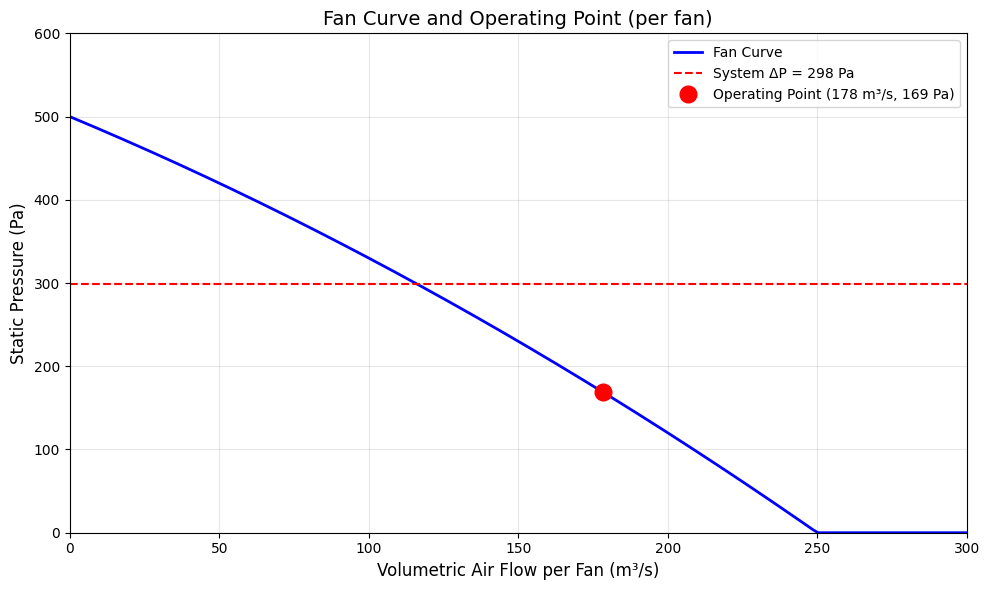


Total air volume flow: 713.1 m³/s
Per-fan flow: 178.3 m³/s (4 fans)
Fan static pressure at operating point: 169.0 Pa
System pressure drop: 298.5 Pa
Fan power: 387.0 kW / 519.0 hp


In [6]:
# Define a typical API 661 fan curve (cubic polynomial)
# P_static = c0 + c1*Q + c2*Q^2 + c3*Q^3
# Q in m³/s per fan, P in Pa
c0, c1, c2, c3 = 500.0, -1.5, -0.002, 0.0

# Apply fan curve to our air cooler
gas2 = SystemSrkEos(273.15 + 80.0, 30.0)
gas2.addComponent("methane", 0.82)
gas2.addComponent("ethane", 0.08)
gas2.addComponent("propane", 0.05)
gas2.addComponent("n-butane", 0.03)
gas2.addComponent("CO2", 0.02)
gas2.setMixingRule("classic")

feed2 = Stream("feed", gas2)
feed2.setFlowRate(500000.0, "kg/hr")
feed2.setTemperature(80.0, "C")
feed2.setPressure(30.0, "bara")

ac2 = AirCooler("AC-102", feed2)
ac2.setOutletTemperature(40.0, "C")
ac2.setAirInletTemperature(25.0, "C")
ac2.setAirOutletTemperature(40.0, "C")
ac2.setRelativeHumidity(0.60)
ac2.setNumberOfTubeRows(4)
ac2.setTubeLength(12.0)
ac2.setBayWidth(3.05)
ac2.setNumberOfBays(2)
ac2.setNumberOfFansPerBay(2)
ac2.setFanDiameter(4.27)
ac2.setFanCurve(c0, c1, c2, c3)

ps2 = ProcessSystem()
ps2.add(feed2)
ps2.add(ac2)
ps2.run()

# Fan curve plot with operating point (per-fan basis)
num_fans = 2 * 2  # 2 bays x 2 fans per bay
q_range = np.linspace(0, 300, 200)
p_fan = c0 + c1 * q_range + c2 * q_range**2 + c3 * q_range**3
p_fan = np.maximum(p_fan, 0)

op_q_total = ac2.getAirVolumeFlow()
op_q_per_fan = op_q_total / num_fans
op_p = ac2.getFanStaticPressure(float(op_q_per_fan))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(q_range, p_fan, "b-", linewidth=2, label="Fan Curve")
ax.axhline(y=ac2.getAirSidePressureDrop(), color="r", linestyle="--",
           linewidth=1.5, label=f"System ΔP = {ac2.getAirSidePressureDrop():.0f} Pa")
if op_q_per_fan > 0 and op_p > 0:
    ax.plot(op_q_per_fan, op_p, "ro", markersize=12,
            label=f"Operating Point ({op_q_per_fan:.0f} m³/s, {op_p:.0f} Pa)")
ax.set_xlabel("Volumetric Air Flow per Fan (m³/s)", fontsize=12)
ax.set_ylabel("Static Pressure (Pa)", fontsize=12)
ax.set_title("Fan Curve and Operating Point (per fan)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 300)
ax.set_ylim(0, max(600, ac2.getAirSidePressureDrop() * 1.5))
plt.tight_layout()
plt.savefig("air_cooler_fan_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal air volume flow: {op_q_total:.1f} m³/s")
print(f"Per-fan flow: {op_q_per_fan:.1f} m³/s ({num_fans} fans)")
print(f"Fan static pressure at operating point: {op_p:.1f} Pa")
print(f"System pressure drop: {ac2.getAirSidePressureDrop():.1f} Pa")
print(f"Fan power: {ac2.getFanPower('kW'):.1f} kW / {ac2.getFanPower('hp'):.1f} hp")

### Thermal Design Summary (JSON Report)

The `AirCooler.toJson()` method returns a comprehensive JSON report including operating conditions, air-side performance, thermal design, bundle geometry, and fan data.

In [7]:
import json

# Get JSON report from the first air cooler run
json_str = ac.toJson()
report = json.loads(str(json_str))

# Pretty-print selected sections
print("=" * 60)
print("AIR COOLER JSON REPORT (selected sections)")
print("=" * 60)

for section in ["operating", "airSide", "thermal", "bundle", "fan"]:
    if section in report:
        print(f"\n--- {section.upper()} ---")
        for key, val in report[section].items():
            if isinstance(val, float):
                print(f"  {key}: {val:.4f}")
            else:
                print(f"  {key}: {val}")

AIR COOLER JSON REPORT (selected sections)

--- AIRSIDE ---
  airMassFlow_kg_s: 828.5000
  airVolumeFlow_m3_s: 713.1423
  airSidePressureDrop_Pa: 298.4990
  faceVelocity_m_s: 9.7424


---

## Part 2: Packed Column (Absorber / Contactor)

The `PackedColumn` class wraps NeqSim's `DistillationColumn` with packing-specific features:
- HETP-based stage equivalence (Onda, Billet-Schultes correlations)
- Flooding analysis (Generalized Pressure Drop Correlation)
- Packing hydraulics (pressure drop, liquid hold-up, wetting)
- 17 built-in packing presets (random and structured)
- Column auto-sizing based on flooding fraction

### Absorber Example — Natural Gas Sweetening with Amine Solvent

In [9]:
# --- Packed Column: Basic Absorber ---
# Gas feed with light hydrocarbons
abs_gas = SystemSrkEos(273.15 + 30.0, 50.0)
abs_gas.addComponent("methane", 0.80)
abs_gas.addComponent("ethane", 0.10)
abs_gas.addComponent("propane", 0.06)
abs_gas.addComponent("n-butane", 0.04)
abs_gas.setMixingRule("classic")

gas_feed = Stream("Sour Gas", abs_gas)
gas_feed.setFlowRate(200000.0, "kg/hr")
gas_feed.setTemperature(30.0, "C")
gas_feed.setPressure(50.0, "bara")

# Lean solvent (heavy hydrocarbon as physical solvent proxy)
solvent_fluid = SystemSrkEos(273.15 + 25.0, 50.0)
solvent_fluid.addComponent("n-heptane", 1.0)
solvent_fluid.setMixingRule("classic")

solvent_feed = Stream("Lean Solvent", solvent_fluid)
solvent_feed.setFlowRate(50000.0, "kg/hr")
solvent_feed.setTemperature(25.0, "C")
solvent_feed.setPressure(50.0, "bara")

# Create packed column
PackedColumn = jneqsim.process.equipment.distillation.PackedColumn
col = PackedColumn("Absorber T-201", gas_feed)

# Configure packing
col.setPackedHeight(8.0)                     # 8 m packed height
col.setPackingType("IMTP-50")                # IMTP #50 random packing
col.setStructuredPacking(False)
col.setDesignFloodFraction(0.70)             # Design at 70% of flood

# Add solvent to column top
col.addSolventStream(solvent_feed)

# Build and run process
ps3 = ProcessSystem()
ps3.add(gas_feed)
ps3.add(solvent_feed)
ps3.add(col)
ps3.run()

# Print results
print("=" * 60)
print("PACKED COLUMN T-201 - Absorber Results")
print("=" * 60)
print(f"Packed height:       {col.getPackedHeight():.1f} m")
print(f"Packing type:        {col.getPackingType()}")
print(f"HETP:                {col.getHETP():.3f} m")
print(f"Theoretical stages:  {col.getTheoreticalStages():.1f}")
print(f"Column diameter:     {col.getInternalDiameter():.3f} m")
print(f"Flood fraction:      {col.getPercentFlood():.1f}%")
print(f"Packing ΔP:          {col.getPackingPressureDrop():.2f} Pa/m")
print(f"Flooding velocity:   {col.getFloodingVelocity():.3f} m/s")
print(f"Hydraulics OK:       {col.isHydraulicsOk()}")

# Gas outlet composition
gas_out = col.getGasOutStream()
print(f"\nGas outlet T:        {gas_out.getTemperature()-273.15:.1f}°C")
print(f"Gas outlet P:        {gas_out.getPressure():.1f} bara")

PACKED COLUMN T-201 - Absorber Results
Packed height:       8.0 m
Packing type:        IMTP-50
HETP:                1.584 m
Theoretical stages:  5.1
Column diameter:     2.000 m
Flood fraction:      65.4%
Packing ΔP:          37.13 Pa/m
Flooding velocity:   0.578 m/s
Hydraulics OK:       True

Gas outlet T:        46.1°C
Gas outlet P:        50.0 bara


### Packing Selection Comparison

Different packings have different capacity and efficiency characteristics. Let's compare several common packings for the same service.

PACKING COMPARISON — 8 m height, 200 t/hr gas, 50 t/hr solvent @ 50 bara
      Packing       Type HETP (m) N_th Dia (m) Flood% dP (Pa/m)  OK
 Pall-Ring-25     Random    0.974  8.2    2.60   64.8      38.0  No
 Pall-Ring-50     Random    1.613  5.0    2.20   58.7      30.7 Yes
      IMTP-25     Random    0.974  8.2    2.60   59.9      29.5  No
      IMTP-50     Random    1.584  5.1    2.00   65.4      37.1 Yes
Mellapak-250Y Structured    0.500 16.0    2.20   58.7      27.2 Yes
Mellapak-500Y Structured    0.300 26.7    2.60   69.4      39.2  No
   Flexipac-2 Structured    1.867  4.3    2.20   58.7      30.9 Yes
    Sulzer-BX Structured    1.867  4.3    2.20   58.7      30.9 Yes


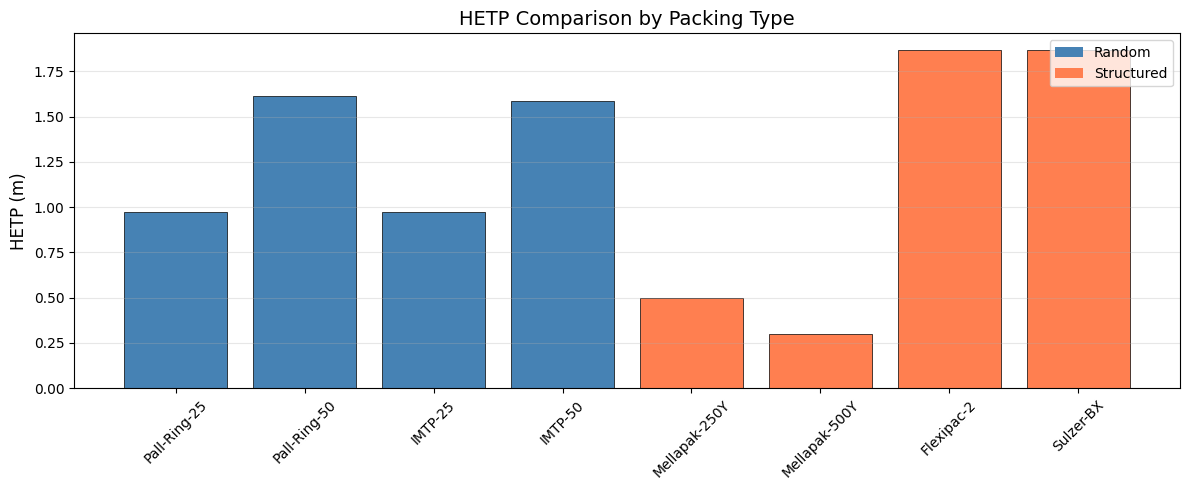


Figure saved: packing_comparison.png


In [10]:
# Compare different packing types
packings = ["Pall-Ring-25", "Pall-Ring-50", "IMTP-25", "IMTP-50",
            "Mellapak-250Y", "Mellapak-500Y", "Flexipac-2", "Sulzer-BX"]

results = []

for packing in packings:
    g = SystemSrkEos(273.15 + 30.0, 50.0)
    g.addComponent("methane", 0.80)
    g.addComponent("ethane", 0.10)
    g.addComponent("propane", 0.06)
    g.addComponent("n-butane", 0.04)
    g.setMixingRule("classic")

    gs = Stream("gas", g)
    gs.setFlowRate(200000.0, "kg/hr")
    gs.setTemperature(30.0, "C")
    gs.setPressure(50.0, "bara")

    sf = SystemSrkEos(273.15 + 25.0, 50.0)
    sf.addComponent("n-heptane", 1.0)
    sf.setMixingRule("classic")

    ss = Stream("solvent", sf)
    ss.setFlowRate(50000.0, "kg/hr")
    ss.setTemperature(25.0, "C")
    ss.setPressure(50.0, "bara")

    pc = PackedColumn("col", gs)
    pc.setPackedHeight(8.0)
    pc.setPackingType(packing)
    is_struct = "Mellapak" in packing or "Flexipac" in packing or "Sulzer" in packing
    pc.setStructuredPacking(is_struct)
    pc.setDesignFloodFraction(0.70)
    pc.addSolventStream(ss)

    psi = ProcessSystem()
    psi.add(gs)
    psi.add(ss)
    psi.add(pc)
    try:
        psi.run()
        results.append({
            "Packing": packing,
            "Type": "Structured" if is_struct else "Random",
            "HETP (m)": f"{pc.getHETP():.3f}",
            "N_th": f"{pc.getTheoreticalStages():.1f}",
            "Dia (m)": f"{pc.getInternalDiameter():.2f}",
            "Flood%": f"{pc.getPercentFlood():.1f}",
            "dP (Pa/m)": f"{pc.getPackingPressureDrop():.1f}",
            "OK": "Yes" if pc.isHydraulicsOk() else "No"
        })
    except Exception as e:
        results.append({
            "Packing": packing, "Type": "Structured" if is_struct else "Random",
            "HETP (m)": "Error", "N_th": "-", "Dia (m)": "-",
            "Flood%": "-", "dP (Pa/m)": "-", "OK": "No"
        })

# Display as table
import pandas as pd
df = pd.DataFrame(results)
print("=" * 90)
print("PACKING COMPARISON — 8 m height, 200 t/hr gas, 50 t/hr solvent @ 50 bara")
print("=" * 90)
print(df.to_string(index=False))

# Bar chart of HETP
fig, ax = plt.subplots(figsize=(12, 5))
valid = [r for r in results if r["HETP (m)"] != "Error"]
names = [r["Packing"] for r in valid]
hetps = [float(r["HETP (m)"]) for r in valid]
colors = ["steelblue" if r["Type"] == "Random" else "coral" for r in valid]
bars = ax.bar(names, hetps, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("HETP (m)", fontsize=12)
ax.set_title("HETP Comparison by Packing Type", fontsize=14)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="steelblue", label="Random"),
                   Patch(facecolor="coral", label="Structured")],
          loc="upper right")
plt.tight_layout()
plt.savefig("packing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved: packing_comparison.png")

### Packed Column JSON Report

The `PackedColumn.toJson()` returns a full report including packing configuration, hydraulic results, and column performance — useful for engineering data handover.

In [11]:
# Get JSON report from the packed column
col_json = col.toJson()
col_report = json.loads(str(col_json))

print("=" * 60)
print("PACKED COLUMN JSON REPORT (selected sections)")
print("=" * 60)

for section in ["packingConfiguration", "hydraulicResults", "columnPerformance"]:
    if section in col_report:
        print(f"\n--- {section} ---")
        for key, val in col_report[section].items():
            if isinstance(val, float):
                print(f"  {key}: {val:.4f}")
            else:
                print(f"  {key}: {val}")

PACKED COLUMN JSON REPORT (selected sections)

--- packingConfiguration ---
  packingType: IMTP-50
  packingCategory: random
  packedHeight_m: 8.0000
  columnDiameter_m: 2.0000
  designFloodFraction: 0.7000

--- hydraulicResults ---
  HETP_m: 1.5840
  theoreticalStages: 5.0505
  percentFlood: 65.4396
  floodingVelocity_ms: 0.5783
  packingPressureDrop_Pa: 37.1263
  packingPressureDrop_mbar: 0.3713
  hydraulicsOk: True
  fsFactor: 2.5188
  kGa: 538.7886
  kLa: 0.0389
  wettedArea_m2m3: 100.4225
  HTU_G_m: 0.0007
  HTU_L_m: 153.6435
  HTU_OG_m: 153.6442

--- columnPerformance ---
  gasOutTemperature_C: 46.0936
  gasOutPressure_bara: 50.0000
  liquidOutTemperature_C: 34.7268
  liquidOutPressure_bara: 50.0000
  converged: True


---

## Part 3: Combined Process — Air Cooler + Packed Column

A common process arrangement: cool a hot gas stream with an air cooler, then feed it to a packed absorber column. This demonstrates how both equipment types integrate in a single `ProcessSystem`.

In [13]:
# Combined process: Air Cooler → Packed Absorber
# Hot hydrocarbon gas cooled then sent to absorber for C3+ recovery

# 1. Hot gas feed
rich_gas = SystemSrkEos(273.15 + 90.0, 40.0)
rich_gas.addComponent("methane", 0.75)
rich_gas.addComponent("ethane", 0.10)
rich_gas.addComponent("propane", 0.08)
rich_gas.addComponent("n-butane", 0.04)
rich_gas.addComponent("n-pentane", 0.03)
rich_gas.setMixingRule("classic")

hot_feed = Stream("Hot Rich Gas", rich_gas)
hot_feed.setFlowRate(300000.0, "kg/hr")
hot_feed.setTemperature(90.0, "C")
hot_feed.setPressure(40.0, "bara")

# 2. Air cooler — cool from 90°C to 35°C
cooler = AirCooler("AC-201", hot_feed)
cooler.setOutletTemperature(35.0, "C")
cooler.setAirInletTemperature(20.0, "C")
cooler.setAirOutletTemperature(35.0, "C")
cooler.setRelativeHumidity(0.50)
cooler.setNumberOfTubeRows(5)
cooler.setTubeLength(12.0)
cooler.setBayWidth(3.05)
cooler.setNumberOfBays(3)
cooler.setNumberOfFansPerBay(2)
cooler.setFanDiameter(4.27)
cooler.setDesignAmbientTemperature(15.0, "C")

# 3. Lean oil solvent for absorption
lean_oil = SystemSrkEos(273.15 + 25.0, 40.0)
lean_oil.addComponent("n-heptane", 1.0)
lean_oil.setMixingRule("classic")

solvent = Stream("Lean Oil", lean_oil)
solvent.setFlowRate(80000.0, "kg/hr")
solvent.setTemperature(25.0, "C")
solvent.setPressure(40.0, "bara")

# 4. Packed column — absorber with Mellapak-250Y structured packing
absorber = PackedColumn("Absorber T-301", cooler.getOutletStream())
absorber.setPackedHeight(10.0)
absorber.setPackingType("Mellapak-250Y")
absorber.setStructuredPacking(True)
absorber.setDesignFloodFraction(0.65)
absorber.addSolventStream(solvent)

# 5. Build and run complete process
combined = ProcessSystem()
combined.add(hot_feed)
combined.add(cooler)
combined.add(solvent)
combined.add(absorber)
combined.run()

# Results summary
print("=" * 70)
print("COMBINED PROCESS: Air Cooler → Packed Absorber")
print("=" * 70)

print("\n--- Air Cooler AC-201 ---")
print(f"  Inlet:      {90.0:.0f}°C → Outlet: {cooler.getOutletStream().getTemperature()-273.15:.1f}°C")
print(f"  Duty:       {-cooler.getDuty()/1e6:.2f} MW")
print(f"  Air flow:   {cooler.getAirMassFlow():.0f} kg/s")
print(f"  Fan power:  {cooler.getFanPower('kW'):.0f} kW")
print(f"  LMTD:       {cooler.getLMTD():.1f} K")
print(f"  Req. area:  {cooler.getRequiredArea():.0f} m²")

print(f"\n--- Packed Column T-301 ---")
print(f"  Packing:    {absorber.getPackingType()} (structured)")
print(f"  Height:     {absorber.getPackedHeight():.0f} m")
print(f"  HETP:       {absorber.getHETP():.3f} m")
print(f"  Stages:     {absorber.getTheoreticalStages():.1f}")
print(f"  Diameter:   {absorber.getInternalDiameter():.2f} m")
print(f"  Flood:      {absorber.getPercentFlood():.1f}%")
print(f"  Hyd. OK:    {absorber.isHydraulicsOk()}")

print(f"\n--- Sweet Gas Out ---")
sweet = absorber.getGasOutStream()
print(f"  Temperature: {sweet.getTemperature()-273.15:.1f}°C")
print(f"  Pressure:    {sweet.getPressure():.1f} bara")

COMBINED PROCESS: Air Cooler → Packed Absorber

--- Air Cooler AC-201 ---
  Inlet:      90°C → Outlet: 35.0°C
  Duty:       11.98 MW
  Air flow:   784 kg/s
  Fan power:  199 kW
  LMTD:       27.7 K
  Req. area:  1325 m²

--- Packed Column T-301 ---
  Packing:    Mellapak-250Y (structured)
  Height:     10 m
  HETP:       0.500 m
  Stages:     20.0
  Diameter:   2.60 m
  Flood:      63.1%
  Hyd. OK:    True

--- Sweet Gas Out ---
  Temperature: 52.6°C
  Pressure:    40.0 bara


## Summary

This notebook demonstrated:

1. **Air-Cooled Heat Exchanger (`AirCooler`)** — Full thermal design with Briggs-Young correlation, Schmidt fin efficiency, LMTD cross-flow correction, Robinson-Briggs air-side pressure drop, fan curves, and ambient temperature sensitivity.

2. **Packed Column (`PackedColumn`)** — Absorber simulation with HETP-based staging, hydraulic analysis as per GPDC/Billet-Schultes, column auto-sizing at specified flooding fraction, and comparison of 8 packing types including random (Pall Ring, IMTP) and structured (Mellapak, Flexipac, Sulzer).

3. **Combined Process** — Integration of both equipment types in a single `ProcessSystem` flowsheet.

### Key References
- API 661 — Air-Cooled Heat Exchangers for General Refinery Service
- Briggs & Young (1963) — Convection heat transfer and pressure drop of air flowing across triangular pitch banks of finned tubes
- Robinson & Briggs (1966) — Pressure drop of air flowing across triangular pitch banks of finned tubes
- Billet & Schultes (1999) — Prediction of mass transfer columns with dumped and arranged packings
- Onda et al. (1968) — Mass transfer coefficients between gas and liquid phases in packed columns